## Optimizacion de Funciones de Perdida 

En este notebook nos enfocamos exclusivamente en optimizar los modelos más
con mejor desempeño del notebook 3: XGBoost y el MLP. Se descartó AdaBoost 
por su inestabilidad ante valores atípicos y Random Forest debido a que su 
rendimiento marginal rara vez justifica el costo computacional de una 
búsqueda exhaustiva.

## 0. Reproducibilidad e imports

In [51]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_recall_curve,
    confusion_matrix, classification_report, roc_curve
)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from xgboost import XGBClassifier
import xgboost as xgb
import copy

SEED = 42
def set_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", DEVICE)   # CPU es suficiente: la red es pequeña


Dispositivo: cpu


##  Carga de datos preprocesados (desde `artifacts/`)

Leemos lo que generó el notebook 1. **No** re-escalamos, **no** re-particionamos y
**no** volvemos a aplicar SMOTE.
- `X_train.csv` → train **escalado y sin balancear con SMOTE** (~50/50).
- `X_val.csv`, `X_test.csv` → val/test **escalados**, con la distribución real (sin SMOTE).

In [41]:
ART = "artifacts"

X_train = pd.read_csv(os.path.join(ART, "X_train_no_res.csv"))
X_val   = pd.read_csv(os.path.join(ART, "X_val.csv"))
X_test  = pd.read_csv(os.path.join(ART, "X_test.csv"))
y_train = pd.read_csv(os.path.join(ART, "y_train_no_res.csv"))["Class"].values
y_val   = pd.read_csv(os.path.join(ART, "y_val.csv"))["Class"].values
y_test  = pd.read_csv(os.path.join(ART, "y_test.csv"))["Class"].values

print("Train:", X_train.shape, "| balance:", np.bincount(y_train))
print("Val:  ", X_val.shape,  "| fraude:", f"{y_val.mean():.4%}")
print("Test: ", X_test.shape, "| fraude:", f"{y_test.mean():.4%}")
INPUT_DIM = X_train.shape[1]   # nº de variables = tamaño de la capa de entrada



Train: (170883, 31) | balance: [170588    295]
Val:   (56962, 31) | fraude: 0.1738%
Test:  (56962, 31) | fraude: 0.1720%


Calculamos el peso para la clase minoritaria (Cost-Sensitive Learning)

Si los datos cargados arriba son los correctos (desbalanceados), esto debería dar ~578.

In [20]:
pos_weight_value = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Peso calculado para la clase minoritaria (Fraude): {pos_weight_value:.2f}")

Peso calculado para la clase minoritaria (Fraude): 578.26


## Optimización de Hiperparámetros para XGBoost

Para optimizar XGBoost, utilizamos RandomizedSearchCV. 
Esta técnica explora un subconjunto aleatorio del 
espacio de hiperparámetros, lo cual es computacionalmente 
más eficiente que un GridSearchCV (búsqueda exhaustiva) y 
ofrece resultados casi idénticos. Además busca 
automáticamente la mejor combinación de árboles, 
profundidad y tasa de aprendizaje optimizando el PR-AUC.

In [58]:
xgb_base = XGBClassifier(
scale_pos_weight=pos_weight_value,
random_state=SEED,
eval_metric='logloss',
n_jobs=-1
)

param_distributions = {
'n_estimators': [100, 300, 500],
'learning_rate': [0.01, 0.05, 0.1, 0.2],
'max_depth': [3, 5, 7],
'subsample': [0.8, 1.0]
}

random_search_xgb = RandomizedSearchCV(
estimator=xgb_base,
param_distributions=param_distributions,
n_iter=10, #n_iter=10 significa que probará 10 combinaciones al azar de todas las posibles
scoring='average_precision',
cv=3,
verbose=2,
random_state=SEED
)

random_search_xgb.fit(X_train.values, y_train)

print(f"\nMejor PR-AUC en validación cruzada: {random_search_xgb.best_score_:.4f}")
print(f"Mejores Hiperparámetros para XGBoost: {random_search_xgb.best_params_}")

best_xgb_model = random_search_xgb.best_estimator_


Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END learning_rate=0.01, max_depth=3, n_estimators=500, subsample=0.8; total time=   4.7s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=500, subsample=0.8; total time=   4.4s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=500, subsample=0.8; total time=   3.8s
[CV] END learning_rate=0.2, max_depth=5, n_estimators=300, subsample=0.8; total time=   2.7s
[CV] END learning_rate=0.2, max_depth=5, n_estimators=300, subsample=0.8; total time=   2.7s
[CV] END learning_rate=0.2, max_depth=5, n_estimators=300, subsample=0.8; total time=   2.6s
[CV] END learning_rate=0.05, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.8s
[CV] END learning_rate=0.05, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.8s
[CV] END learning_rate=0.05, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.8s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.8s
[C

Consecuencias de cambiar parametros en XGBoost:
1. n_estimators (Cantidad de árboles):
- Subirlo: Permite aprender patrones más complejos, pero aumenta el riesgo de sobreajuste.
- Bajarlo: Evita el sobreajuste pero puede causar subajuste (el modelo no aprende suficiente).

2. learning_rate (Tasa de aprendizaje):
- Valores altos (0.2): El modelo aprende muy rápido, dando saltos grandes en la optimización. Puede pasarse del mínimo global de error.
- Valores bajos (0.01): Aprende paso a pasito. Es muy preciso pero requiere muchísimos árboles (n_estimators) para terminar de aprender.

3. max_depth (Profundidad del árbol):
- Valores altos (7): El árbol crece mucho y encuentra relaciones complejas. Alto riesgo de memorizar el ruido (sobreajuste).
- Valores bajos (3): Árboles simples y generales.

4. subsample (Fracción de datos usada por árbol):
- Bajarlo a 0.8: Cada árbol solo ve el 80% de los datos. Previene que el modelo memorice el dataset (reduce la varianza).

## 2. Preparación para el MLP (DataLoaders)

Convertimos los DataFrames a tensores y los servimos por lotes.
**No usamos `pos_weight`:** el train ya está balanceado por SMOTE, así que ponderar
además la pérdida sería corregir dos veces el desbalance.


In [ ]:
HIDDEN_DIMS = [32, 16]   # 2 capas ocultas (la rúbrica pide 1-3)
DROPOUT     = 0.3
LR          = 1e-3
WEIGHT_DECAY= 1e-4       # regularización L2 (idea de Ridge)
BATCH_SIZE  = 2048
MAX_EPOCHS  = 40
PATIENCE    = 8          # early stopping sobre PR-AUC de validación

def make_loader(Xdf, yarr, shuffle):
    Xt = torch.tensor(Xdf.values, dtype=torch.float32)
    yt = torch.tensor(np.asarray(yarr), dtype=torch.float32).unsqueeze(1)  # (N,1) para casar con la salida
    ds = TensorDataset(Xt, yt)
    g = torch.Generator().manual_seed(SEED)   # barajado reproducible
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, generator=g)

train_loader = make_loader(X_train, y_train, shuffle=True)   # barajar SOLO en entrenamiento
val_loader   = make_loader(X_val,   y_val,   shuffle=False)
test_loader  = make_loader(X_test,  y_test,  shuffle=False)


## 3. Arquitectura del MLP

Red **pequeña a propósito**: bloques `Linear → BatchNorm → ReLU → Dropout`.
- **BatchNorm** estabiliza el entrenamiento con entradas heterogéneas.
- **ReLU** aporta la no linealidad (sin ella, apilar capas = un modelo lineal).
- **Dropout (0.3)** regulariza.
- Salida = **1 logit**; la sigmoide vive dentro de `BCEWithLogitsLoss` por estabilidad numérica.

In [22]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropout):
        super().__init__()
        layers, prev = [], input_dim  # 'layers' acumula las capas; 'prev' = tamaño de entrada actual
        # Por cada tamaño de capa oculta (aquí [32, 16]) añadimos un bloque de 4 piezas:
        # 'Linear' capa densa: combina las 'prev' entradas en 'h' salidas (aquí se aprende)
        # 'BatchNorm' normaliza esas h salidas -> entrenamiento más estable y rápido
        # 'ReLu' activación no lineal: deja pasar positivos, anula negativos
        # apaga al azar el 30% de neuronas al entrenar (regularización)
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))   # capa final: 1 logit (sin activación; la sigmoide vive en la pérdida)
        self.net = nn.Sequential(*layers)  # encadena todas las capas en orden
    def forward(self, x):   # forward define cómo fluye un dato 'x' por la red, de la entrada a la salida.
        return self.net(x)

set_seed(SEED)
model = MLP(INPUT_DIM, HIDDEN_DIMS, DROPOUT).to(DEVICE)
print(model)
print("Parámetros:", sum(p.numel() for p in model.parameters()))




MLP(
  (net): Sequential(
    (0): Linear(in_features=31, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=16, out_features=1, bias=True)
  )
)
Parámetros: 1665


## 4. Entrenamiento Sensible al Costo (*Cost-Sensitive*) con *early stopping*

Utilizamos una pérdida **BCE ponderada** (*BCEWithLogitsLoss* con `pos_weight`) para gestionar el desbalanceo de clases directamente desde la función de optimización. Validamos cada época mediante la métrica PR-AUC sobre el conjunto de validación (manteniendo la distribución real de los datos) y guardamos únicamente el mejor estado del modelo. El *weight_decay* de Adam aporta regularización L2 para mejorar la generalización.

In [38]:
# @torch.no_grad(): desactiva el rastreo de gradientes en toda esta función (solo predecimos, no entrenamos).
@torch.no_grad()
def predict_proba(model, loader):
    model.eval()  # modo evaluación: apaga Dropout y fija BatchNorm
    probs, ys = [], []  # listas para ir guardando probabilidades y etiquetas reales
    for xb, yb in loader:
        p = torch.sigmoid(model(xb.to(DEVICE))).cpu().numpy().ravel()  # model(xb) da logits -> sigmoide los pasa a probabilidad -> a CPU, a numpy, y aplanado a 1D
        probs.append(p); ys.append(yb.numpy().ravel())
    return np.concatenate(probs), np.concatenate(ys)

def train_model(model, train_loader, val_loader, optimizer, criterion, max_epochs=50, patience=4, verbose=False):
    
   
    history = {"train_loss": [], "val_loss": [], "val_ap": []}
    best_ap, best_state, bad = -1.0, None, 0
    for epoch in range(1, max_epochs + 1):
        model.train() # modo entrenamiento: Dropout y BatchNorm activos
        running = 0.0 # acumulador de la pérdida de esta época
        for xb, yb in train_loader:
            
            optimizer.zero_grad() # borramos los gradientes del paso anterior
            loss = criterion(model(xb), yb)  # la red predice y medimos el error (forward)
            loss.backward() # backpropagation: calcula cuánto "culpa" tiene cada peso del error
            optimizer.step() # optimizador ajusta los pesos para bajar el error
            running += loss.item() * xb.size(0) # sumamos la pérdida del lote (×tamaño del lote)
        train_loss = running / len(train_loader.dataset) # pérdida media de la época

        #validación
        model.eval()
        with torch.no_grad(): # sin gradientes: más rápido y ligero
            vloss = 0.0
            for xb, yb in val_loader:
                
                vloss += criterion(model(xb), yb).item() * xb.size(0) # acumula pérdida de validación
            vloss /= len(val_loader.dataset) # pérdida media de validación
        vp, vy = predict_proba(model, val_loader) # probabilidades y etiquetas de validación
        val_ap = average_precision_score(vy, vp) # PR-AUC de validación (nuestra métrica real)
        
        history["train_loss"].append(train_loss)
        history["val_loss"].append(vloss)
        history["val_ap"].append(val_ap)
        if verbose:
            print(f"Época {epoch:02d} | train {train_loss:.4f} | val {vloss:.4f} | val PR-AUC {val_ap:.4f}")
            
        # early stopping basado en el PR-AUC de validació
        if val_ap > best_ap: # ¿mejoró el PR-AUC de validación?
            best_ap, best_state,bad = val_ap, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0 # sí: guardamos ESTOS pesos
        else:
            bad += 1 # no: contamos una época sin mejora
            if bad >= patience: # si van 8 seguidas sin mejorar
                if verbose: print(f"Early stopping en época {epoch} (mejor PR-AUC val: {best_ap:.4f})")
                break
                
    if best_state is not None: model.load_state_dict(best_state) # restauramos los MEJORES pesos (no los de la última época)
    return model, best_ap







In [42]:
print("\n--- Iniciando Búsqueda de Hiperparámetros para MLP con Early Stopping ---")

mlp_configs = [
{"hidden_dims": [16, 8], "dropout": 0.1, "lr": 1e-3, "name": "Red Pequeña (Bajo Dropout)"},
{"hidden_dims": [32, 16], "dropout": 0.3, "lr": 1e-3, "name": "Red Media (Dropout Estándar)"},
{"hidden_dims": [64, 32, 16], "dropout": 0.4, "lr": 5e-4, "name": "Red Profunda (Alto Dropout)"}
]


criterio = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight_value))

best_mlp_ap = 0
best_mlp_config = None
best_mlp_model = None

for config in mlp_configs:
    print(f"\nEntrenando Configuración: {config['name']}")

model = MLP(X_train.shape[1], config["hidden_dims"], config["dropout"])
# El optimizador y la arquitectura se configuran dinámicamente
optimizer = optim.Adam(model.parameters(), lr=config["lr"], weight_decay=1e-4)

# Recibimos únicamente el modelo entrenado y su score final
model, best_ap_val = train_model(
    model, train_loader, val_loader, optimizer, criterio, 
    max_epochs=50, patience=4, verbose=True
)

print(f"  -> Mejor PR-AUC (Validación) para esta config: {best_ap_val:.4f}")

if best_ap_val > best_mlp_ap:
    best_mlp_ap = best_ap_val
    best_mlp_config = config
    best_mlp_model = copy.deepcopy(model)

print(f"\n============================================================")
print(f"MEJOR CONFIGURACIÓN MLP ENCONTRADA:")
print(f"Topología: {best_mlp_config['name']}")
print(f"PR-AUC (Validación): {best_mlp_ap:.4f}")
print(f"============================================================")


--- Iniciando Búsqueda de Hiperparámetros para MLP con Early Stopping ---

Entrenando Configuración: Red Pequeña (Bajo Dropout)

Entrenando Configuración: Red Media (Dropout Estándar)

Entrenando Configuración: Red Profunda (Alto Dropout)
Época 01 | train 1.3093 | val 1.0675 | val PR-AUC 0.3490
Época 02 | train 1.0275 | val 0.8357 | val PR-AUC 0.5661
Época 03 | train 0.8891 | val 0.7346 | val PR-AUC 0.6191
Época 04 | train 0.7724 | val 0.6536 | val PR-AUC 0.6533
Época 05 | train 0.7108 | val 0.6108 | val PR-AUC 0.6661
Época 06 | train 0.6450 | val 0.5525 | val PR-AUC 0.6504
Época 07 | train 0.5995 | val 0.5215 | val PR-AUC 0.6637
Época 08 | train 0.5390 | val 0.4882 | val PR-AUC 0.6668
Época 09 | train 0.5043 | val 0.4693 | val PR-AUC 0.6737
Época 10 | train 0.4712 | val 0.4497 | val PR-AUC 0.6833
Época 11 | train 0.4576 | val 0.4388 | val PR-AUC 0.6689
Época 12 | train 0.4409 | val 0.4243 | val PR-AUC 0.6750
Época 13 | train 0.4076 | val 0.4104 | val PR-AUC 0.6832
Época 14 | train 0.

## 5. Evaluación del MLP en TEST


--- XGBoost Optimizado ---
ROC-AUC: 0.9743 | PR-AUC: 0.8768
Umbral óptimo (Max F1): 0.4062

Matriz de Confusión:
[[56853    11]
 [   14    84]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0     0.9998    0.9998    0.9998     56864
           1     0.8842    0.8571    0.8705        98

    accuracy                         0.9996     56962
   macro avg     0.9420    0.9285    0.9351     56962
weighted avg     0.9996    0.9996    0.9996     56962



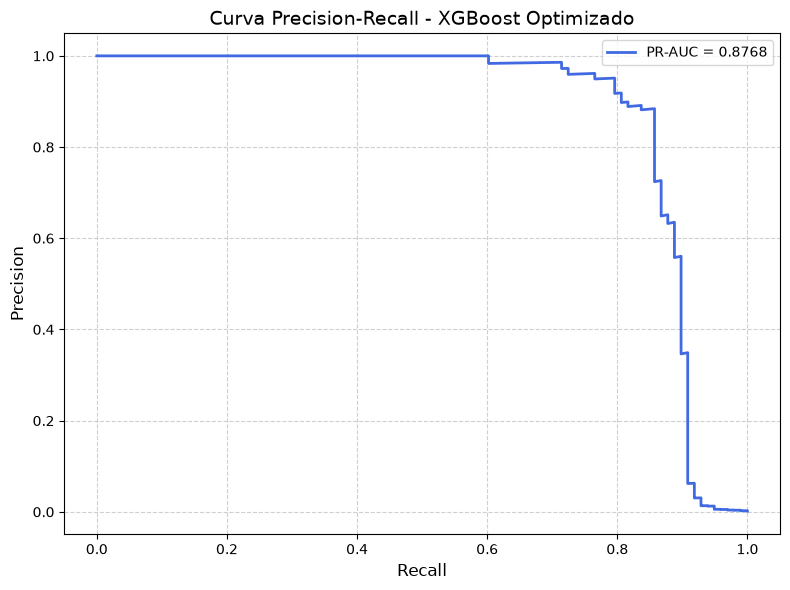


--- MLP Optimizado ---
ROC-AUC: 0.9712 | PR-AUC: 0.7162
Umbral óptimo (Max F1): 0.9980

Matriz de Confusión:
[[56846    18]
 [   18    80]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0     0.9997    0.9997    0.9997     56864
           1     0.8163    0.8163    0.8163        98

    accuracy                         0.9994     56962
   macro avg     0.9080    0.9080    0.9080     56962
weighted avg     0.9994    0.9994    0.9994     56962



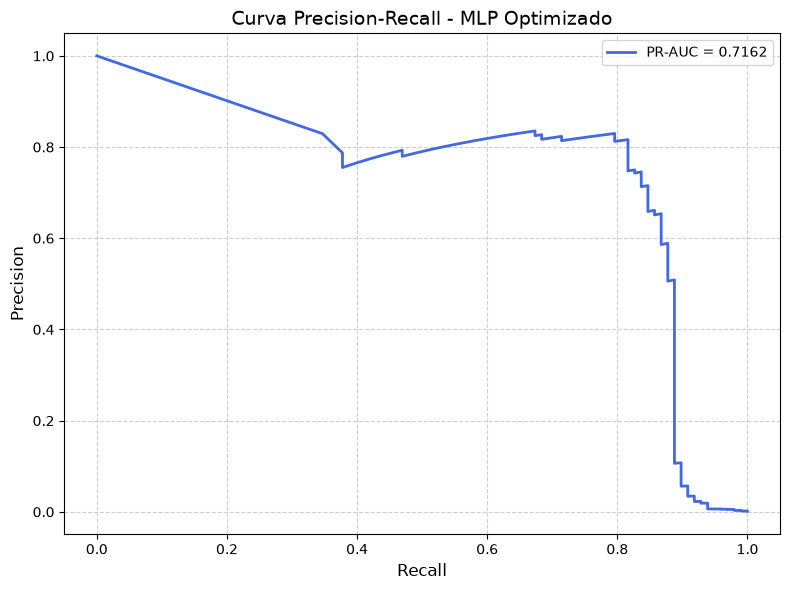

In [54]:
def evaluate_model(name, y_true, y_probs):
    roc_auc = roc_auc_score(y_true, y_probs)
    pr_auc = average_precision_score(y_true, y_probs)
    print(f"\n--- {name} ---")
    print(f"ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f}")
    # Calculo del umbral óptimo
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1_scores)
    best_thr = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    print(f"Umbral óptimo (Max F1): {best_thr:.4f}")
    y_pred = (y_probs >= best_thr).astype(int)
    print("\nMatriz de Confusión:")
    print(confusion_matrix(y_true, y_pred))
    print("\nReporte de Clasificación:")
    print(classification_report(y_true, y_pred, digits=4))
    return roc_auc, pr_auc, best_thr


def plot_curves(name, y_true, y_probs):
    plt.figure(figsize=(8, 6))
    
    # Curva PR
    prec, rec, _ = precision_recall_curve(y_true, y_probs)
    ap = average_precision_score(y_true, y_probs)
    
    plt.plot(rec, prec, label=f"PR-AUC = {ap:.4f}", color='royalblue', lw=2)
    plt.title(f"Curva Precision-Recall - {name}", fontsize=14)
    plt.xlabel("Recall", fontsize=12)
    plt.ylabel("Precision", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# Predicciones finales de XGBoost
xgb_test_probs = best_xgb_model.predict_proba(X_test.values)[:, 1]
# Predicciones finales del MLP
mlp_test_probs, _ = predict_proba(best_mlp_model, test_loader)

# Evalua y Grafica XGBoost Optimizado
evaluate_model("XGBoost Optimizado", y_test, xgb_test_probs)
plot_curves("XGBoost Optimizado", y_test, xgb_test_probs)

# Evalua y Grafica MLP Optimizado
evaluate_model("MLP Optimizado", y_test, mlp_test_probs)
plot_curves("MLP Optimizado", y_test, mlp_test_probs)

## 9. Comparativa Final


--- Gráfica Comparativa Final  ---


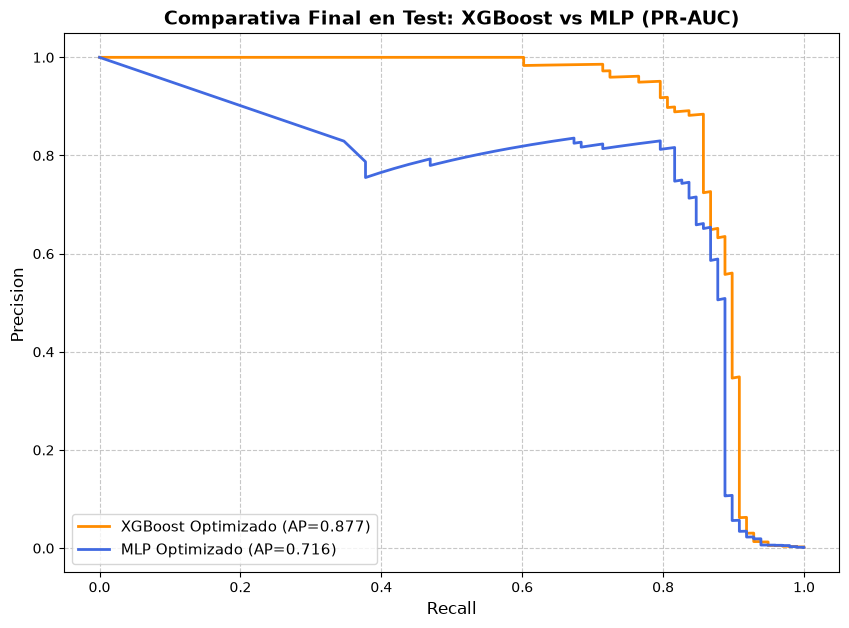

In [57]:

print("\n--- Gráfica Comparativa Final  ---")
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, xgb_test_probs)
precision_mlp, recall_mlp, _ = precision_recall_curve(y_test, mlp_test_probs)

plt.figure(figsize=(10, 7))
plt.plot(recall_xgb, precision_xgb, label=f'XGBoost Optimizado (AP={average_precision_score(y_test, xgb_test_probs):.3f})', color='darkorange', lw=2)
plt.plot(recall_mlp, precision_mlp, label=f'MLP Optimizado (AP={average_precision_score(y_test, mlp_test_probs):.3f})', color='royalblue', lw=2)

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision ', fontsize=12)
plt.title('Comparativa Final en Test: XGBoost vs MLP (PR-AUC)', fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

¿Qué pasa al cambiar los hiperparámetros en el MLP?

Las Redes Neuronales son altamente sensibles a su 
arquitectura. Evaluamos iterativamente tres 
topologías diferentes combinadas con Early Stopping 
para observar su comportamiento y evitar el 
sobreajuste:

1. hidden_dims (Arquitectura de Capas Ocultas):

- Redes pequeñas 
$$16, 8$$
: Obligan al modelo a comprimir mucho la información. 
Extraen solo los patrones más fuertes pero pueden 
perder sutilezas.

- Redes profundas 
$$64, 32, 16$$
: Mucha capacidad matemática. Excelente para detectar 
fraude complejo, pero alto riesgo de aprender el ruido 
de las PCA de memoria.

2. dropout (Tasa de "olvido"):
- Valores bajos (0.1): La red retiene casi toda la 
información. Bueno si la red es pequeña.
- Valores altos (0.4): Apaga el 40% de las neuronas 
en cada paso. Obliga a la red profunda a ser robusta 
y no depender de un solo patrón para predecir fraude.

3. lr (Tasa de Aprendizaje del optimizador Adam):
- Mismo principio que en XGBoost: dicta la agresividad 
con la que los pesos se actualizan durante el 
backpropagation.

In [ ]:
# Guardado de métricas reproducibles
import json as _json
os.makedirs("artifacts", exist_ok=True)
torch.save(model.state_dict(), "artifacts/mlp_fraud.pt")
metrics = {
"xgboost_optimizado_pr_auc": float(average_precision_score(y_test, xgb_test_probs)),
"xgboost_optimizado_roc_auc": float(roc_auc_score(y_test, xgb_test_probs)),
"best_xgb_params": random_search_xgb.best_params_,

"mlp_optimizado_pr_auc": float(average_precision_score(y_test, mlp_test_probs)),
"mlp_optimizado_roc_auc": float(roc_auc_score(y_test, mlp_test_probs)),
"best_mlp_config": best_mlp_config,

"seed": SEED
}
with open("artifacts/optimizacion_metrics.json", "w") as f:
    _json.dump(metrics, f, indent=2)
print("Guardado en artifacts/:", metrics)